In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\netflix_titles.csv", encoding='latin1')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [6]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [8]:
df.select_dtypes(include=['int64','float64']).columns

Index(['release_year'], dtype='str')

In [10]:
df.select_dtypes(include='str').columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [11]:
df['show_id'].is_unique

True

The Netflix Titles dataset contains information about movies and TV shows available on Netflix. It includes the title, director, cast, country, release year, date added, rating, duration, genre, and description. The dataset is useful for analyzing Netflix's content library, production trends, ratings, and genres.

In [12]:
# Missing values 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
# Missing Percentage
(df.isnull().sum()/len(df))*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [15]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


Duplicate Records: The dataset was checked for duplicate rows. No duplicate records were found (0 duplicates), so no rows were removed.

In [16]:
# Lowercase the column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ","_")

In [17]:
# Remove Extra Spaces
df = df.apply(lambda x: x.str.strip() if x.dtype=="object" else x)

In [18]:
# Fill Missing Values-Director
df["director"] = df["director"].fillna("Unknown")

In [19]:
# Cast
df["cast"] = df["cast"].fillna("Unknown")

In [20]:
# Country
df["country"] = df["country"].fillna("Unknown")

In [21]:
# Rating
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [22]:
# Duration 
df["duration"] = df["duration"].fillna("Unknown")

In [23]:
# Convert Date
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [24]:
# Check Missing Values Again
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [25]:
# Cleaning Summary
summary = pd.DataFrame({
    "Issue Found":[
        "Missing Values",
        "Duplicate Records",
        "Column Names",
        "Date Format",
        "Extra Spaces"
    ],
    "Action Taken":[
        "Filled",
        "Removed",
        "Standardized",
        "Converted to Datetime",
        "Trimmed"
    ]
})

summary

,Issue Found,Action Taken
0,Missing Values,Filled
1,Duplicate Records,Removed
2,Column Names,Standardized
3,Date Format,Converted to Datetime
4,Extra Spaces,Trimmed


In [29]:
df.to_csv(r"C:\Users\Admin\Documents\NetflixTitles_Cleaned.csv", index=False)

In [26]:
# Summary Statistics- Numerical
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [28]:
# Summary Statistics- Categorical
df.describe(include='str')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,17,221,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,3211,1793,362,4


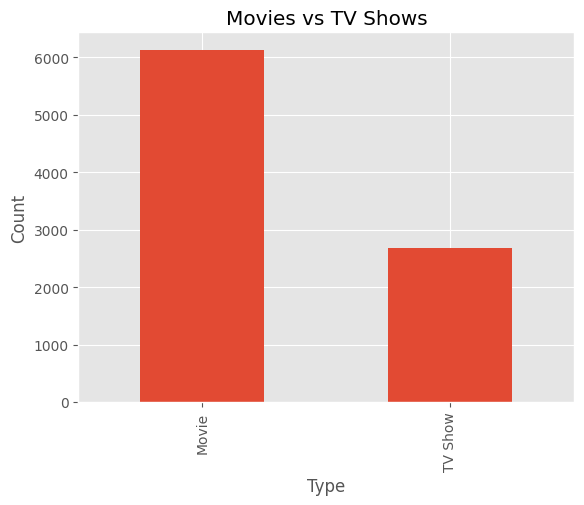

In [30]:
# EDA-Movies and TV shows
df["type"].value_counts()
df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Movies make up a larger share of Netflix's content library than TV Shows, indicating that Netflix offers a greater variety of movies to its subscribers.

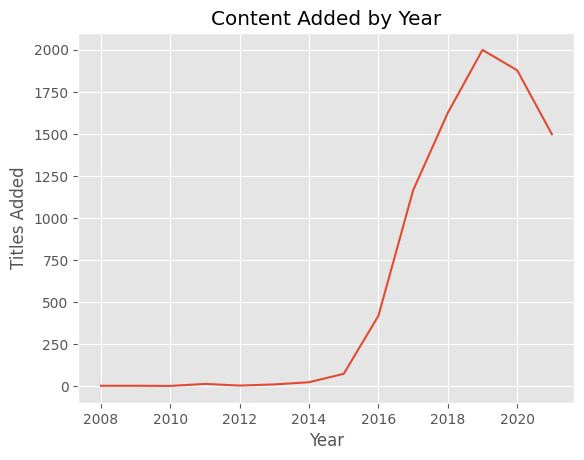

In [31]:
# Content added by Year
df["year_added"] = df["date_added"].dt.year
df["year_added"].value_counts().sort_index().plot(kind="line")

plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.show()

The number of titles added to Netflix increased over the years, reaching a peak before declining slightly in recent years. This reflects Netflix's rapid expansion of its content library during that period.

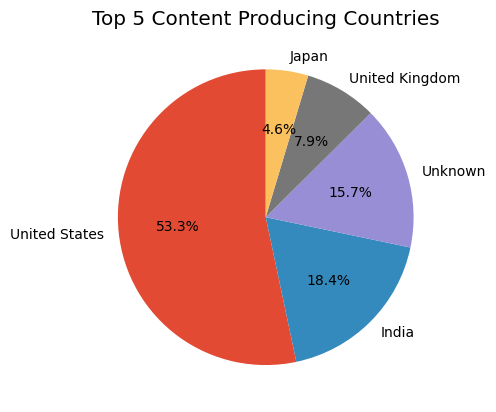

In [34]:
# Top 5 Countries
top5 = df["country"].value_counts().head(5)

top5.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Content Producing Countries")
plt.ylabel("")
plt.show()

The majority of Netflix titles come from a few countries, with the United States contributing the largest share of the available content.

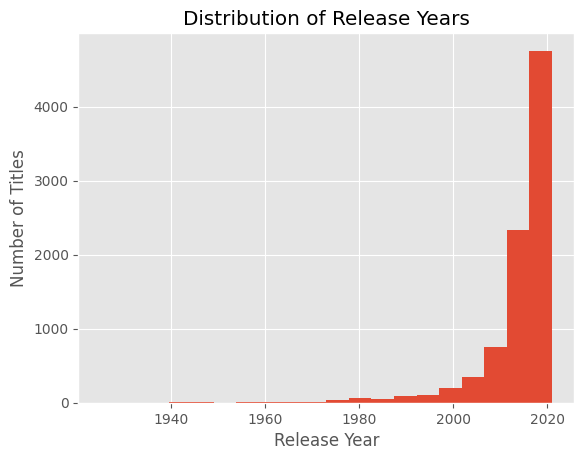

In [35]:
# Release year Distributon
plt.hist(df["release_year"], bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

Most Netflix titles were released in recent years, indicating that the platform focuses on providing relatively modern content while maintaining a smaller collection of older titles.

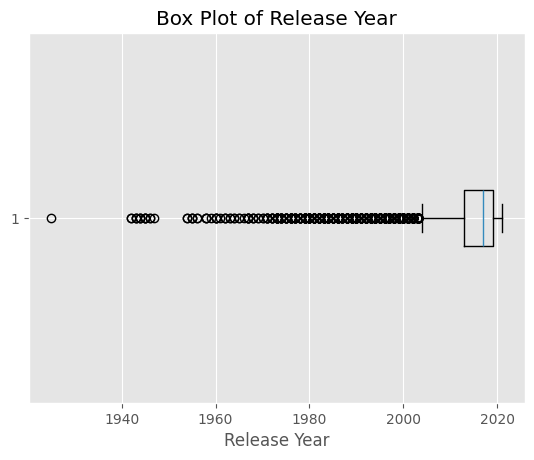

In [36]:
# Release Year
plt.boxplot(df["release_year"], vert=False)

plt.title("Box Plot of Release Year")
plt.xlabel("Release Year")
plt.show()

Most Netflix titles were released in recent years. The box plot shows that the middle 50% of release years are concentrated within a relatively recent period, while a few much older titles appear as outliers.

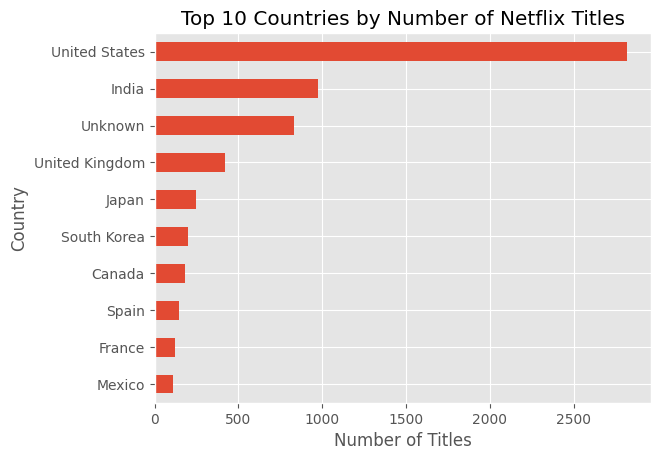

In [38]:
# Top 10 Countries
top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

# Put the highest value at the top
plt.gca().invert_yaxis()

plt.show()

The United States has the highest number of Netflix titles, followed by India and the United Kingdom. This indicates that Netflix's content library is dominated by productions from a few major countries.

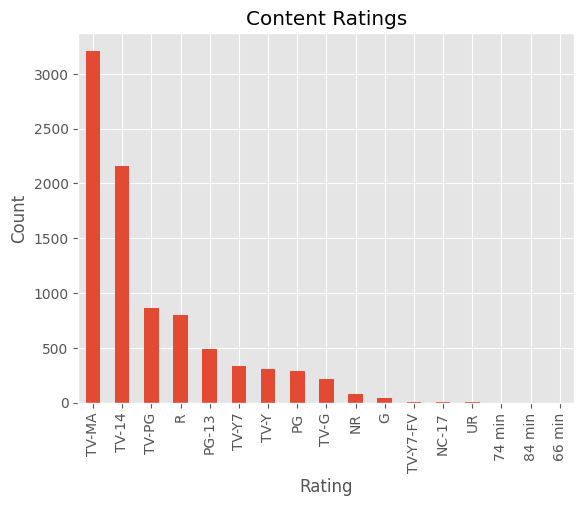

In [39]:
# Ratings 
df["rating"].value_counts().plot(kind="bar")

plt.title("Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

TV-MA and TV-14 are the most common content ratings on Netflix, indicating that the platform primarily offers content intended for mature and teenage audiences.

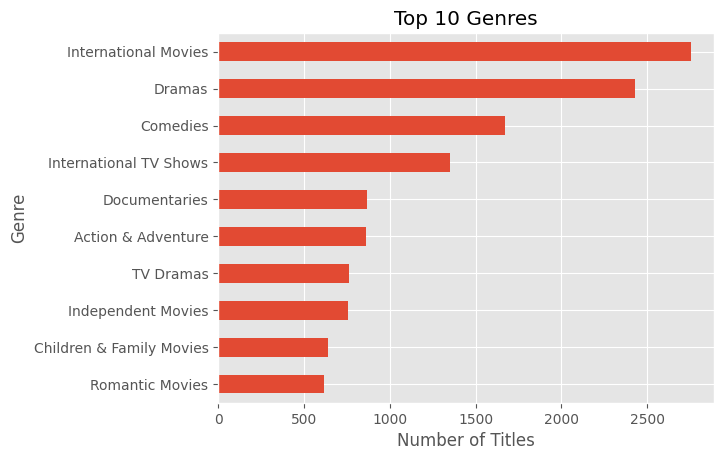

In [40]:
# Top Genres
top_genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

top_genres.plot(kind="barh")

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.gca().invert_yaxis()

plt.show()

International Movies, Dramas, and Comedies are among the most common genres on Netflix, indicating that the platform offers a diverse range of content to cater to different audience preferences.